# Monte Carlo ($\pi$) Performance Benchmark Notebook

This notebook estimates \(\pi\) using a Monte Carlo method and compares runtime performance across multiple implementations:

- **Pure Python loop**
- **NumPy vectorized version**
- **Numba JIT-compiled version**
- **Numba parallel version**
- **C++ compiled version**

## Workflow

1. Define a range of sample sizes \(N\) (from small to very large).
2. Run each implementation multiple times per \(N\).
3. Compute average execution time for fair comparison.
4. Record \(\pi\) estimates and timing results.
5. Visualize scaling behavior with **log-log plots**.
6. Compare methods on a single chart.
7. Compute **parallel speedup** relative to standard Numba.

## Goal

Identify which implementation is fastest and how performance scales as the number of random points increases.

N=100      pi≈3.00000000 avg_time=0.000031s
N=1000     pi≈3.16800000 avg_time=0.000317s
N=10000    pi≈3.11680000 avg_time=0.003189s
N=100000   pi≈3.15032000 avg_time=0.032588s
N=1000000  pi≈3.13832000 avg_time=0.342001s
N=10000000 pi≈3.14162200 avg_time=3.271650s
N=100000000 pi≈3.14148764 avg_time=32.229948s


N=100      pi≈3.00000000 avg_time=0.000031s
N=1000     pi≈3.16800000 avg_time=0.000317s
N=10000    pi≈3.11680000 avg_time=0.003189s
N=100000   pi≈3.15032000 avg_time=0.032588s
N=1000000  pi≈3.13832000 avg_time=0.342001s
N=10000000 pi≈3.14162200 avg_time=3.271650s
N=100000000 pi≈3.14148764 avg_time=32.229948s


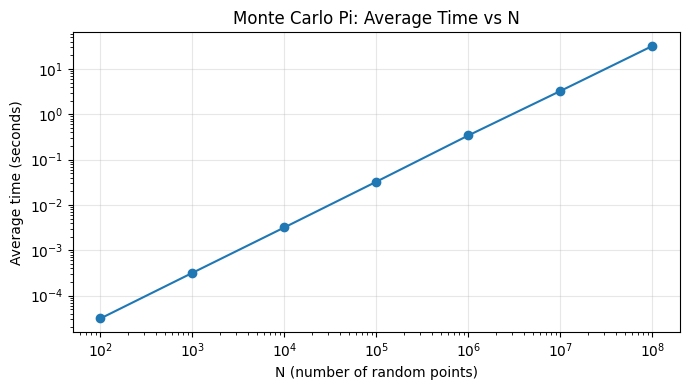

In [1]:
import timeit
import matplotlib.pyplot as plt

from pi_python import calc_pi_loop

#Initialize lists to store n vlaues and specify number of repeats for timing
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
repeats = 10
#Initialize lists to store average times and pi estimates for each method
avg_times_python = []
pi_estimates_python = []

# Calculate pi estimates and average times for the pure Python implementation, sweep n values
for n in n_values:
    pi_estimates_python.append(calc_pi_loop(n))
    avg_time = timeit.timeit(lambda: calc_pi_loop(n), number=repeats) / repeats
    avg_times_python.append(avg_time)

for n, pi_val, t in zip(n_values, pi_estimates_python, avg_times_python):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")

# Plotting the results for the pure Python implementation. Time vs n on a log-log scale
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_python, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



N=100      pi≈3.16000000 avg_time=0.000006s
N=1000     pi≈3.21200000 avg_time=0.000012s
N=10000    pi≈3.15800000 avg_time=0.000076s
N=100000   pi≈3.15384000 avg_time=0.001639s
N=1000000  pi≈3.14400400 avg_time=0.007981s
N=10000000 pi≈3.14145360 avg_time=0.079966s
N=100000000 pi≈3.14163644 avg_time=0.843720s


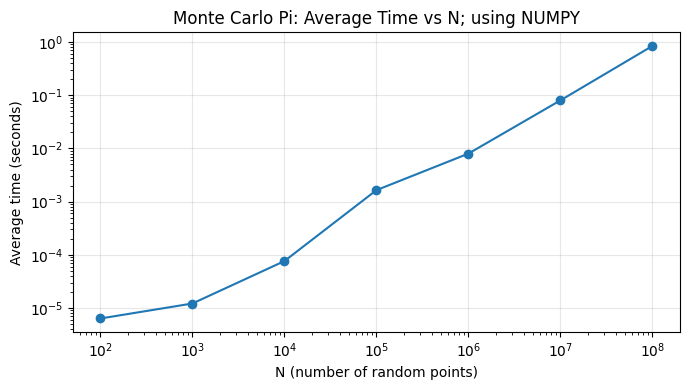

In [2]:
from pi_numpy import calc_pi_numpy
#Initialize lists to store n vlaues and specify number of repeats for timing
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
repeats = 5
#Initialize lists to store average times and pi estimates for the NumPy implementation
avg_times_numpy = []
pi_estimates_numpy = []
# Calculate pi estimates and average times for the NumPy implementation, sweep n values
for n in n_values:
    pi_estimates_numpy.append(calc_pi_numpy(n))
    avg_time = timeit.timeit(lambda: calc_pi_numpy(n), number=repeats) / repeats
    avg_times_numpy.append(avg_time)

for n, pi_val, t in zip(n_values, pi_estimates_numpy, avg_times_numpy):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")
# Plotting the results for the NumPy implementation. Time vs n on a log-log scale
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_numpy, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N; using NUMPY")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

N=100      pi≈3.24000000 avg_time=0.000001s
N=1000     pi≈3.12800000 avg_time=0.000009s
N=10000    pi≈3.14280000 avg_time=0.000088s
N=100000   pi≈3.14104000 avg_time=0.000891s
N=1000000  pi≈3.14306000 avg_time=0.008870s
N=10000000 pi≈3.14161360 avg_time=0.088986s
N=100000000 pi≈3.14162812 avg_time=0.887965s


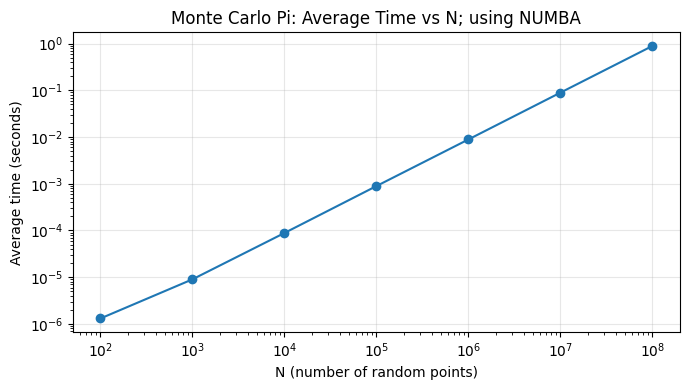

N=100      pi≈3.24000000 avg_time=0.000001s
N=1000     pi≈3.12800000 avg_time=0.000009s
N=10000    pi≈3.14280000 avg_time=0.000088s
N=100000   pi≈3.14104000 avg_time=0.000891s
N=1000000  pi≈3.14306000 avg_time=0.008870s
N=10000000 pi≈3.14161360 avg_time=0.088986s
N=100000000 pi≈3.14162812 avg_time=0.887965s


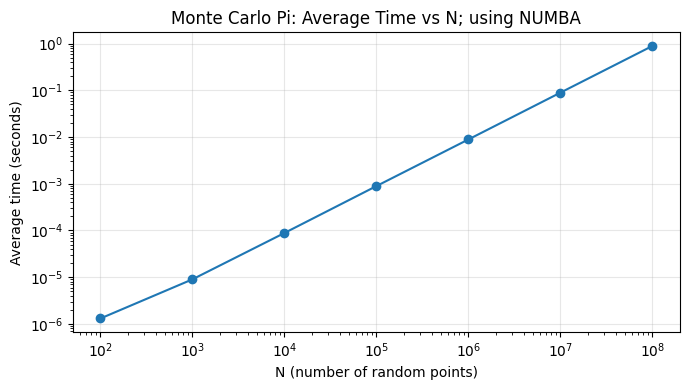

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


N=100      pi≈3.24000000 avg_time=0.000001s
N=1000     pi≈3.12800000 avg_time=0.000009s
N=10000    pi≈3.14280000 avg_time=0.000088s
N=100000   pi≈3.14104000 avg_time=0.000891s
N=1000000  pi≈3.14306000 avg_time=0.008870s
N=10000000 pi≈3.14161360 avg_time=0.088986s
N=100000000 pi≈3.14162812 avg_time=0.887965s


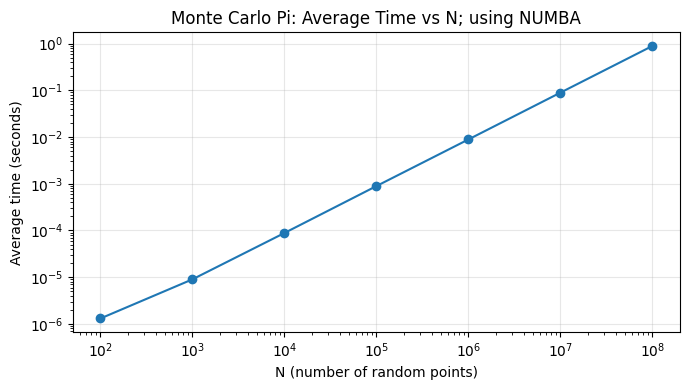

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


N=100      pi≈3.16000000 avg_time=0.000062s
N=1000     pi≈3.04400000 avg_time=0.000049s
N=10000    pi≈3.14040000 avg_time=0.000061s
N=100000   pi≈3.13984000 avg_time=0.000133s
N=1000000  pi≈3.14089600 avg_time=0.000943s
N=10000000 pi≈3.14111560 avg_time=0.008699s
N=100000000 pi≈3.14156140 avg_time=0.080816s


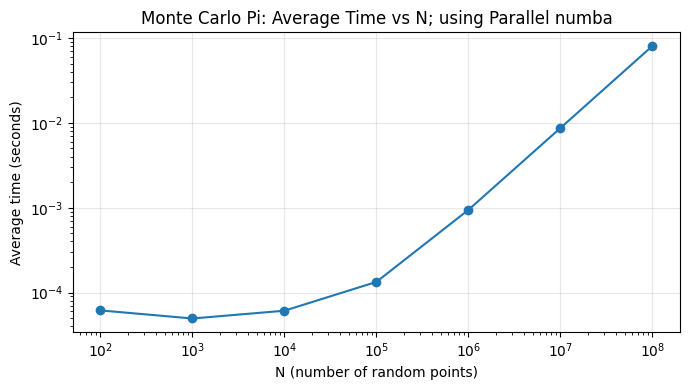

In [3]:
from pi_numba import calc_pi_numba, calc_pi_parallel
#Initialize lists to store n vlaues and specify number of repeats for timing
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
repeats = 5
#Initialize lists to store average times and pi estimates for the Numba implementation
avg_times_numba = []
pi_estimates_numba = []
# Calculate pi estimates and average times for the Numba implementation, sweep n values
for n in n_values:
    pi_estimates_numba.append(calc_pi_numba(n))
    avg_time = timeit.timeit(lambda: calc_pi_numba(n), number=repeats) / repeats
    avg_times_numba.append(avg_time)

for n, pi_val, t in zip(n_values, pi_estimates_numba, avg_times_numba):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")
# Plotting the results for the Numba implementation. Time vs n on a log-log scale
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_numba, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N; using NUMBA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Initialize lists to store average times and pi estimates for the Parallel Numba implementation
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]

avg_times_parallel = []
pi_estimates_parallel = []
# Calculate pi estimates and average times for the Parallel Numba implementation, sweep n values
for n in n_values:
    pi_estimates_parallel.append(calc_pi_parallel(n))
    avg_time = timeit.timeit(lambda: calc_pi_parallel(n), number=repeats) / repeats
    avg_times_parallel.append(avg_time)

for n, pi_val, t in zip(n_values, pi_estimates_parallel, avg_times_parallel):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")
# Plotting the results for the Parallel Numba implementation. Time vs n on a log-log scale
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_parallel, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N; using Parallel numba")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
import numpy as np
print("Parallel speedup:", np.array(avg_times_numba) / np.array(avg_times_parallel))

Parallel speedup: [ 0.02126047  0.1822172   1.4458569   6.68289214  9.40792966 10.22951781
 10.98751512]


Compiling main.cpp...
Compilation successful!

N=100      pi≈3.20000000 avg_time=0.006011s
N=1000     pi≈3.03200000 avg_time=0.004717s
N=10000    pi≈3.13360000 avg_time=0.004084s
N=100000   pi≈3.14296000 avg_time=0.004621s
N=1000000  pi≈3.14125000 avg_time=0.012988s
N=10000000 pi≈3.14202000 avg_time=0.095642s
N=100000000 pi≈3.14176000 avg_time=0.921285s


Compiling main.cpp...
Compilation successful!

N=100      pi≈3.20000000 avg_time=0.006011s
N=1000     pi≈3.03200000 avg_time=0.004717s
N=10000    pi≈3.13360000 avg_time=0.004084s
N=100000   pi≈3.14296000 avg_time=0.004621s
N=1000000  pi≈3.14125000 avg_time=0.012988s
N=10000000 pi≈3.14202000 avg_time=0.095642s
N=100000000 pi≈3.14176000 avg_time=0.921285s


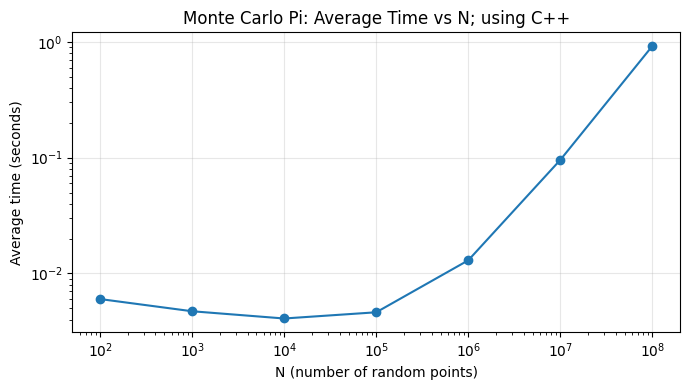

In [4]:
import subprocess
import timeit
import matplotlib.pyplot as plt 

# Compile the C++ program
print("Compiling main.cpp...")
compile_result = subprocess.run(
    ["g++", "-O3", "-std=c++11", "main.cpp", "-o", "mc_pi"],
    capture_output=True,
    text=True
)

if compile_result.returncode != 0:
    print("Compilation failed:")
    print(compile_result.stderr)
else:
    print("Compilation successful!\n")
    
    # Benchmark the C++ implementation
    n_values = [ 10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
    repeats = 5
    avg_times_cpp = []
    pi_estimates_cpp = []
    
    for n in n_values:
        # Get pi estimate from one run
        result = subprocess.run(
            ["./mc_pi", str(n)],
            capture_output=True,
            text=True
        )
        if result.returncode == 0:
            output = result.stdout.strip()
            pi_val = float(output.split("pi=")[1])
            pi_estimates_cpp.append(pi_val)
        
        # Time multiple runs using timeit
        avg_time = timeit.timeit(
            lambda n=n: subprocess.run(["./mc_pi", str(n)], capture_output=True, text=True),
            number=repeats
        ) / repeats
        
        avg_times_cpp.append(avg_time)
        print(f"N={n:<8d} pi≈{pi_estimates_cpp[-1]:.8f} avg_time={avg_time:.6f}s")
    
    # Plot C++ results
    plt.figure(figsize=(7, 4))
    plt.plot(n_values, avg_times_cpp, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("N (number of random points)")
    plt.ylabel("Average time (seconds)")
    plt.title("Monte Carlo Pi: Average Time vs N; using C++")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Using Cyhton

In [ ]:
import sys
import importlib
from pathlib import Path

calc_pi_dir = Path("calc_pi").resolve()
if str(calc_pi_dir) not in sys.path:
    sys.path.insert(0, str(calc_pi_dir))

# Remove possibly-cached namespace package to avoid name collision
sys.modules.pop("calc_pi", None)

calc_pi = importlib.import_module("calc_pi")
calc_pi_cython = calc_pi.calc_pi_cython

print("Import successful, now running Cython benchmarks...")

Import successful, now running Cython benchmarks...


N=100      pi≈2.84000000 avg_time=0.000002s
N=1000     pi≈3.18400000 avg_time=0.000016s
N=10000    pi≈3.14240000 avg_time=0.000162s
N=100000   pi≈3.14912000 avg_time=0.001535s
N=1000000  pi≈3.13980400 avg_time=0.013558s
N=10000000 pi≈3.14143240 avg_time=0.133262s
N=100000000 pi≈3.14163912 avg_time=1.321137s


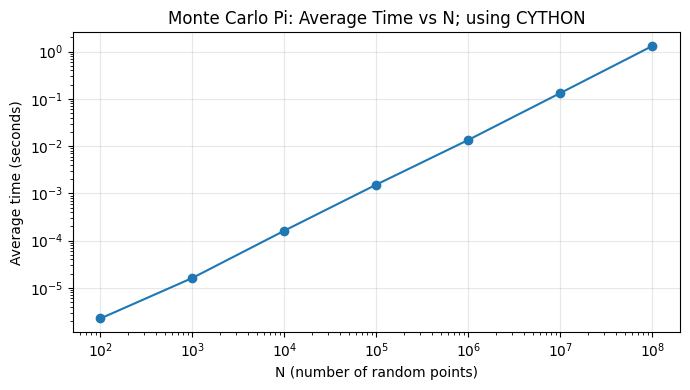

In [ ]:
# Benchmark Cython implementation
import timeit
import matplotlib.pyplot as plt

# Use the same n_values as other implementations
n_values = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7, 10**8]
repeats = 5

# Initialize lists to store average times and pi estimates for the Cython implementation
avg_times_cython = []
pi_estimates_cython = []

# Calculate pi estimates and average times for the Cython implementation, sweep n values
for n in n_values:
    pi_estimates_cython.append(calc_pi_cython(n))
    avg_time = timeit.timeit(lambda n=n: calc_pi_cython(n), number=repeats) / repeats
    avg_times_cython.append(avg_time)

for n, pi_val, t in zip(n_values, pi_estimates_cython, avg_times_cython):
    print(f"N={n:<8d} pi≈{pi_val:.8f} avg_time={t:.6f}s")

# Plotting the results for the Cython implementation. Time vs n on a log-log scale
plt.figure(figsize=(7, 4))
plt.plot(n_values, avg_times_cython, marker="o")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Average Time vs N; using CYTHON")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare methods for to find the fastest method

Method: python
Method: numpy
Method: numba
Method: parallel
Method: cpp
Method: cython


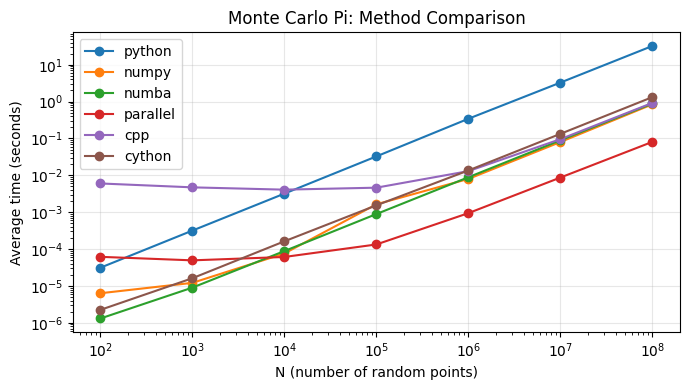

In [26]:
methods = ['python','numpy','numba', 'parallel', 'cpp', 'cython']

times_by_method = {
    "python": avg_times_python,
    "numpy": avg_times_numpy,
    "numba": avg_times_numba,
    "parallel": avg_times_parallel,
    "cpp": avg_times_cpp,
    "cython": avg_times_cython,
}

plt.figure(figsize=(7, 4))
for method in methods:
    times = times_by_method.get(method)
    if times is None:
        print(f"Skipping {method}: no timing data found.")
        continue
    print(f"Method: {method}")
    plt.plot(n_values, times, marker="o", label=method)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Average time (seconds)")
plt.title("Monte Carlo Pi: Method Comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("mc_methods_comparison.png")
plt.show()

In [14]:
# Quick benchmark using available implementations
print("=" * 60)
print("Quick Benchmark")
print("=" * 60)

from time import time

logn = 8
n = 10**logn

# Test all available methods
methods_to_test = {
    "Python": calc_pi_loop,
    "NumPy": calc_pi_numpy,
    "Numba": calc_pi_numba,
    "Numba Parallel": calc_pi_parallel,
}

for method_name, method_func in methods_to_test.items():
    start = time()
    pi = method_func(n)
    end = time()
    print(f"{method_name:<18s}: π ≈ {pi:.8f}  Time: {end - start:.3f}s")

print("=" * 60)

✗ Cython import failed: cannot import name 'calc_pi_cython' from 'calc_pi' (unknown location)
Using Numba as fallback

Estimated Pi: 3.14131276
Method: Numba (fallback)
Samples: 10^8
Time: 0.919s


## Exploratory Timing Table (Five Implementations)

This section benchmarks five implementations (Python, NumPy, Numba, C++, Cython) over a small range of problem sizes to build intuition.

Recorded metrics:
- Problem size (`n`)
- Total execution time (seconds)
- Samples per second (`n / time`)
- Time per sample (`time / n`)
- Additional comments on behavior (memory/performance characteristics)

In [34]:
try:
    import pandas as pd
except Exception:
    pd = None

times_by_method = {
    "Python": avg_times_python,
    "NumPy": avg_times_numpy,
    "Numba": avg_times_numba,
    "C++": avg_times_cpp,
    "Cython": avg_times_cython,
}

rows = []
for method_name, times in times_by_method.items():
    if not times:
        print(f"Skipping {method_name}: no timing data found.")
        continue

    for n, total_time in zip(n_values, times):
        rows.append(
            {
                "Method": method_name,
                "n": n,
                "total_time_s": total_time,
                "samples_per_second": n / total_time if total_time > 0 else float("inf"),
                "time_per_sample_s_per_n": total_time / n,
            }
        )

if pd is not None:
    timing_df = pd.DataFrame(rows)
    timing_df["total_time_s"] = timing_df["total_time_s"].map(lambda x: f"{x:.6f}")
    timing_df["samples_per_second"] = timing_df["samples_per_second"].map(lambda x: f"{x:,.2f}")
    timing_df["time_per_sample_s_per_n"] = timing_df["time_per_sample_s_per_n"].map(lambda x: f"{x:.3e}")
    display(timing_df)
else:
    print("Method | n | total_time_s | samples_per_second | time_per_sample_s_per_n")
    print("-" * 95)
    for row in rows:
        print(
            f"{row['Method']:7s} | {row['n']:10d} | {row['total_time_s']:.6f} | "
            f"{row['samples_per_second']:14.2f} | {row['time_per_sample_s_per_n']:.3e}"
        )

txt_path = "exploratory_timing_table.txt"
with open(txt_path, "w", encoding="utf-8") as f:
    f.write("Method | n | total_time_s | samples_per_second | time_per_sample_s_per_n\n")
    f.write("-" * 95 + "\n")
    for row in rows:
        f.write(
            f"{row['Method']:7s} | {row['n']:10d} | {row['total_time_s']:.6f} | "
            f"{row['samples_per_second']:14.2f} | {row['time_per_sample_s_per_n']:.3e}\n"
        )

print(f"Saved timing table to {txt_path}")

,Method,n,total_time_s,samples_per_second,time_per_sample_s_per_n
0,Python,100,0.000031,"3,205,981.23",3.119e-07
1,Python,1000,0.000317,"3,155,611.40",3.169e-07
2,Python,10000,0.003189,"3,136,070.13",3.189e-07
3,Python,100000,0.032588,"3,068,644.43",3.259e-07
4,Python,1000000,0.342001,"2,923,972.23",3.420e-07
5,Python,10000000,3.271650,"3,056,561.47",3.272e-07
6,Python,100000000,32.229948,"3,102,704.37",3.223e-07
7,NumPy,100,0.000006,"15,789,305.09",6.333e-08
8,NumPy,1000,0.000012,"82,529,977.08",1.212e-08
9,NumPy,10000,0.000076,"131,607,700.53",7.598e-09


Saved timing table to exploratory_timing_table.txt


In [37]:
import pandas as pd

times_by_method = {
    "Python": avg_times_python,
    "NumPy": avg_times_numpy,
    "Numba": avg_times_numba,
    "Parallel": avg_times_parallel,
    "C++": avg_times_cpp,
    "Cython": avg_times_cython,
}

rows = []
for method, times in times_by_method.items():
    for n, total_time in zip(n_values, times):
        rows.append({
            "Method": method,
            "n": n,
            "total_time_s": total_time,
            "samples_per_second": n / total_time,
            "time_per_sample_s_per_n": total_time / n,
        })

timing_df_simple = pd.DataFrame(rows)
display(timing_df_simple)

timing_df_simple.to_csv("exploratory_timing_table.csv", index=False)
timing_df_simple.to_string(open("exploratory_timing_table.txt", "w"), index=False)
print("Saved exploratory_timing_table.csv and exploratory_timing_table.txt")

,Method,n,total_time_s,samples_per_second,time_per_sample_s_per_n
0,Python,100,0.000031,3.205981e+06,3.119170e-07
1,Python,1000,0.000317,3.155611e+06,3.168958e-07
2,Python,10000,0.003189,3.136070e+06,3.188704e-07
3,Python,100000,0.032588,3.068644e+06,3.258768e-07
4,Python,1000000,0.342001,2.923972e+06,3.420005e-07
5,Python,10000000,3.271650,3.056561e+06,3.271650e-07
6,Python,100000000,32.229948,3.102704e+06,3.222995e-07
7,NumPy,100,0.000006,1.578931e+07,6.333401e-08
8,NumPy,1000,0.000012,8.252998e+07,1.211681e-08
9,NumPy,10000,0.000076,1.316077e+08,7.598340e-09


Saved exploratory_timing_table.csv and exploratory_timing_table.txt


# Statistical Analysis: Monte Carlo Pi Estimation Across Sample Sizes

## Objective

Generate robust statistical data for the Monte Carlo π estimation method by:
- Running **10 independent samples** for each sample size
- Testing across a wide range: **N = 10³ to 10⁹**
- Computing key metrics for each N value:
    - **π estimate** (mean across 10 samples)
    - **Absolute error** (|estimate - π|)
    - **Standard deviation** (variability across samples)
    - **Runtime** (total execution time)
    - **Time per sample** (runtime / N)
    - **Throughput** (samples processed per second)

## Output Format

Results will be stored in a structured CSV file with the following columns:

| Column | Description |
|--------|-------------|
| `n` | Number of random samples |
| `pi_estimate` | Mean π estimate across 10 runs |
| `absolute_error` | \|π_estimate - π\| |
| `std_dev` | Standard deviation of estimates |
| `runtime_sec` | Total execution time (seconds) |
| `time_per_sample` | Average time per sample (runtime / N) |
| `samples_per_sec` | Throughput (N / runtime) |

## Expected Insights

This statistical approach reveals:
- **Convergence behavior**: How estimate accuracy improves with larger N
- **Performance scaling**: Whether computational time scales linearly with N
- **Efficiency metrics**: Which N values offer best accuracy-to-cost tradeoff
- **Variability**: Statistical stability of the Monte Carlo method at different scales

In [101]:
from pi_numba import calc_pi_numba, calc_pi_parallel
import time
import numpy as np
import random

BASE_SEED = 12345

#Initialize lists to store n vlaues and specify number of repeats for timing
n_values = [ 10**3, 10**4, 10**5, 10**6, 10**7, 10**8, 10**9, 10**10]
n_samples = 10

total_runtimes = []
pi_estimate_list = []
time_per_sample=[]
samples_per_second=[]
abs_error_pi_list = []
std_dev_pi_list = []

for idx, n in enumerate(n_values):
    seed = BASE_SEED + idx
    random.seed(seed)
    np.random.seed(seed)

    pi_estimates = []
    time_estimates = []
    for _ in range(n_samples):
        start_time = time.perf_counter()
        pi_estimate = calc_pi_parallel(n)
        end_time = time.perf_counter()
        pi_estimates.append(pi_estimate)
        time_estimates.append(end_time - start_time)

    total_runtimes.append(sum(time_estimates)) #Total Runtime for all samples
    mean_pi_estimate = sum(pi_estimates) / n_samples #Mean pi estimate across samples
    pi_estimate_list.append(mean_pi_estimate)
    abs_error_pi = abs(mean_pi_estimate - np.pi)
    abs_error_pi_list.append(abs_error_pi) #Absolute error of pi estimate
    std_dev_pi = np.std(pi_estimates)
    std_dev_pi_list.append(std_dev_pi) #Standard deviation of pi estimates
    avg_time = sum(time_estimates) / n_samples #Average time per sample
    time_per_sample.append(avg_time) #Time per sample (average time divided by n)
    samples_per_second.append(1/avg_time) #Samples per second (1 divided by average time per sample)

    print(f"N={n:<8d} seed={seed} mean π ≈ {mean_pi_estimate:.8f} abs_error={abs_error_pi:.8f} std_dev={std_dev_pi:.8f} time_per_sample={avg_time:.6f}s samples_per_second={1/avg_time:.2f}") 

N=1000     seed=12345 mean π ≈ 3.12160000 abs_error=0.01999265 std_dev=0.04672301 time_per_sample=0.000141s samples_per_second=7069.23
N=10000    seed=12346 mean π ≈ 3.15240000 abs_error=0.01080735 std_dev=0.01424696 time_per_sample=0.000141s samples_per_second=7110.89
N=100000   seed=12347 mean π ≈ 3.14269600 abs_error=0.00110335 std_dev=0.00536684 time_per_sample=0.000153s samples_per_second=6545.93
N=1000000  seed=12348 mean π ≈ 3.14175840 abs_error=0.00016575 std_dev=0.00149572 time_per_sample=0.001007s samples_per_second=993.11
N=10000000 seed=12349 mean π ≈ 3.14134764 abs_error=0.00024501 std_dev=0.00064069 time_per_sample=0.009702s samples_per_second=103.07
N=100000000 seed=12350 mean π ≈ 3.14157944 abs_error=0.00001322 std_dev=0.00013794 time_per_sample=0.091385s samples_per_second=10.94
N=1000000000 seed=12351 mean π ≈ 3.14159692 abs_error=0.00000426 std_dev=0.00005088 time_per_sample=0.840350s samples_per_second=1.19
N=10000000000 seed=12352 mean π ≈ 3.14159386 abs_error=0.00

In [ ]:
rows = []

# # Recover if `time_per_sample` was accidentally overwritten to a float
# time_per_sample_values = (
#     time_per_sample
#     if isinstance(time_per_sample, list)
#     else [rt / n_samples for rt in total_runtimes]
# )

for n, pi_estimate, total_time, abs_error, std_dev, tps, sps in zip(
    n_values,
    pi_estimate_list,
    total_runtimes,
    abs_error_pi_list,
    std_dev_pi_list,
    time_per_sample,
    samples_per_second,
):
    rows.append({
        "N": n,
        "π estimate ": pi_estimate,
        "Total Runtime (s)": total_time,
        "Absolute Error of π Estimate": abs_error,
        "Standard Deviation of π Estimates": std_dev,
        "Time per Sample (s)": tps,
        "Samples per Second": sps
    })

timing_df_simple = pd.DataFrame(rows)
display(timing_df_simple)

timing_df_simple.to_csv("fastest_method_data.csv", index=False)
timing_df_simple.to_string(open("fastest_method_table.txt", "w"), index=False)
print("Saved fastest_method_data.csv and fastest_method_table.txt")

,N,π estimate,Total Runtime (s),Absolute Error of π Estimate,Standard Deviation of π Estimates,Time per Sample (s),Samples per Second
0,1000,3.121600,0.001415,0.019993,0.046723,0.000141,7069.226019
1,10000,3.152400,0.001406,0.010807,0.014247,0.000141,7110.894198
2,100000,3.142696,0.001528,0.001103,0.005367,0.000153,6545.929738
3,1000000,3.141758,0.010069,0.000166,0.001496,0.001007,993.105947
4,10000000,3.141348,0.097019,0.000245,0.000641,0.009702,103.072505
5,100000000,3.141579,0.913853,0.000013,0.000138,0.091385,10.942676
6,1000000000,3.141597,8.403501,0.000004,0.000051,0.840350,1.189980
7,10000000000,3.141594,82.615627,0.000001,0.000017,8.261563,0.121042


Saved fastest_method_data.csv and fastest_method_table.txt


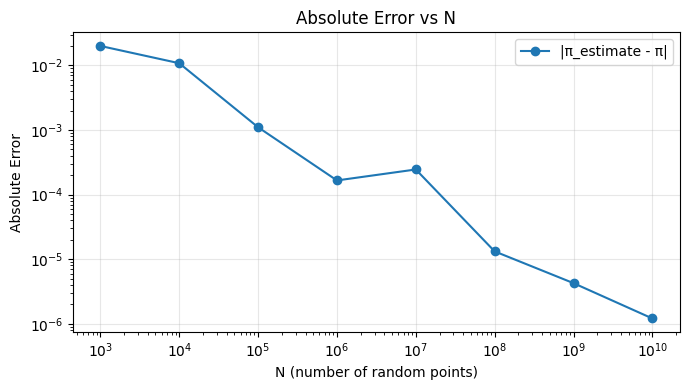

In [103]:
plt.figure(figsize=(7, 4))
plt.plot(n_values, abs_error_pi_list, marker="o", label="|π_estimate - π|")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (number of random points)")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs N")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

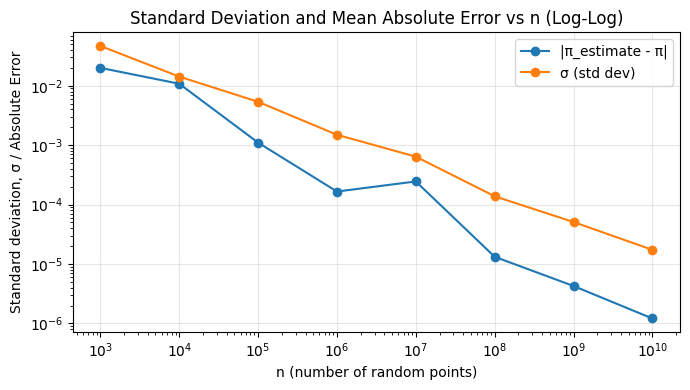

In [110]:
# Overplot standard deviation (σ) vs n on a log-log scale
plt.figure(figsize=(7, 4))
plt.plot(n_values, abs_error_pi_list, marker="o", label="|π_estimate - π|")
plt.plot(n_values, std_dev_pi_list, marker="o", label="σ (std dev)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (number of random points)")
plt.ylabel("Standard deviation, σ / Absolute Error")
plt.title("Standard Deviation and Mean Absolute Error vs n (Log-Log)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("abs_error_std_dev_overplot.png")
plt.show()

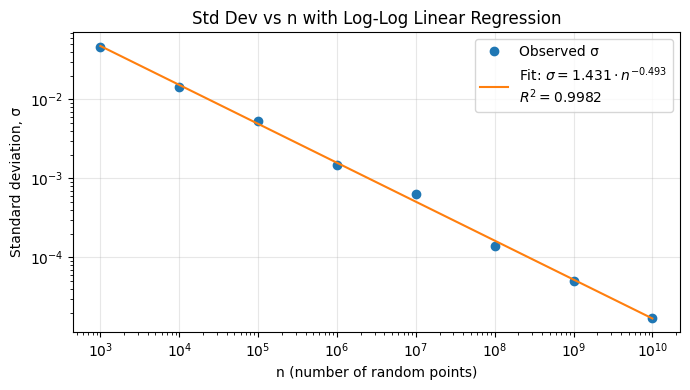

log10(σ) = -0.492796 * log10(n) + 0.155509
Power law uncertainty: ±0.008651
Intercept uncertainty: ±0.059623
Power law: σ = (1.430571e+00 ± 1.963975e-01) * n^-0.492796
R^2 (log space) = 0.998154


In [113]:
# Log-log linear regression fit: std_dev vs n
x = np.array(n_values, dtype=float)
y = np.array(std_dev_pi_list, dtype=float)

mask = (x > 0) & (y > 0)
logx = np.log10(x[mask])
logy = np.log10(y[mask])

(slope, intercept), cov = np.polyfit(logx, logy, 1, cov=True)
logy_fit = slope * logx + intercept
y_fit = 10 ** logy_fit

slope_err = np.sqrt(cov[0, 0])
intercept_err = np.sqrt(cov[1, 1])
A = 10 ** intercept
A_err = A * np.log(10) * intercept_err

# R^2 in log space
ss_res = np.sum((logy - logy_fit) ** 2)
ss_tot = np.sum((logy - np.mean(logy)) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")

plt.figure(figsize=(7, 4))
plt.plot(x, y, "o", label="Observed σ")
plt.plot(
    x[mask],
    y_fit,
    "-",
    label=(
        f"Fit: $\\sigma = {A:.3f} \\cdot n^{{{slope:.3f}}}$\n"
        f"$R^2={r2:.4f}$"
    ),
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("n (number of random points)")
plt.ylabel("Standard deviation, σ")
plt.title("Std Dev vs n with Log-Log Linear Regression")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
#plt.savefig("fastest_method_std_dev_fit.png")
plt.show()

print(f"log10(σ) = {slope:.6f} * log10(n) + {intercept:.6f}")
print(f"Power law uncertainty: ±{slope_err:.6f}")
print(f"Intercept uncertainty: ±{intercept_err:.6f}")
print(f"Power law: σ = ({A:.6e} ± {A_err:.6e}) * n^{slope:.6f}")
print(f"R^2 (log space) = {r2:.6f}")